# PHẦN 2: TIỀN XỬ LÝ DỮ LIỆU VÀ PHÂN TÍCH (PREPROCESSING) - HỒI QUY

## 1. Thiết lập & Cấu hình

### 1.1 Import các thư viện cần thiết

In [1]:
# Standard library imports
import sys
import os
import warnings
import pickle
from pathlib import Path

# Scientific computing
import numpy as np
import pandas as pd
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Pipeline & Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Statsmodels
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Suppress warnings
warnings.filterwarnings('ignore')

### 1.2 Thiết lập Random Seed để đảm bảo tính tái hiện

In [2]:
# Add parent directory to path for importing utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils import set_seed, load_dataset, train_val_test_split

SEED = 42
set_seed(SEED)

### 1.3 Cấu hình Visualization toàn cục

In [3]:
# Global matplotlib configuration
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10
})

# Seaborn theme
sns.set_theme(style='whitegrid', palette='muted')
COLORS = sns.color_palette('tab10')

### 1.4 Tải Dataset

In [4]:
# Define data paths
DATA_RAW_DIR = os.path.join('..', '..', '..', 'data', 'raw', 'regression')
DATA_FILE = os.path.join(DATA_RAW_DIR, 'hour.csv')

# Load the dataset
df = load_dataset(DATA_FILE)

# Display basic shape
n_rows, n_cols = df.shape
print(f"Shape: {n_rows:,} rows × {n_cols} columns")

Shape: 17,379 rows × 17 columns


### 1.5 Kiểm tra Missing Values 


In [5]:
# Explicit missing-value check before any preprocessing
missing_before = df.isnull().sum()
missing_total = int(missing_before.sum())

print('Missing values per column (before preprocessing):')
display(missing_before.to_frame(name='missing_count').T)
print(f'Total missing values: {missing_total}')

Missing values per column (before preprocessing):


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Total missing values: 0


**Kết luận:** Dữ liệu hiện không có missing value. Tuy nhiên, pipeline vẫn giữ bước imputation để đảm bảo tính robust khi deployment trên dữ liệu mới.

**Kết luận:** Đã tải thành công thư viện, thiết lập cấu hình và tải bộ dữ liệu gốc `hour.csv` với 17,379 mẫu và 17 đặc trưng.

## 2. Tiền xử lý Dữ liệu (Data Preprocessing)

Dựa trên các phân tích từ EDA, chúng ta sẽ thực hiện xử lý dữ liệu. Để đảm bảo tính bền vững (robustness) và module hóa (Mục 10.2.1 trong tài liệu thiết kế), quy trình sẽ được đóng gói bằng `sklearn.pipeline`.

### 2.1 Trích xuất Đặc trưng (Feature Engineering)

In [6]:
# 1. Drop features based on EDA
# - instant: Record index
# - dteday: Date object (temporal info captured in season, yr, mnth, hr, weekday)
# - casual, registered: Data leakage (cnt = casual + registered)
# - atemp: High multicollinearity with temp (VIF > 50)
cols_to_drop = ['instant', 'dteday', 'casual', 'registered', 'atemp']
df = df.drop(columns=cols_to_drop)

# 2. Create new features
# is_rush_hour: Peak hours 7-9 and 17-19
df['is_rush_hour'] = df['hr'].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)

# time_of_day: 0=night(0-5), 1=morning(6-11), 2=afternoon(12-17), 3=evening(18-23)
def get_time_of_day(hr):
    if 0 <= hr <= 5: return 0
    elif 6 <= hr <= 11: return 1
    elif 12 <= hr <= 17: return 2
    else: return 3

df['time_of_day'] = df['hr'].apply(get_time_of_day)

# temp_hum_interaction: Interaction term between temperature and humidity
df['temp_hum_interaction'] = df['temp'] * df['hum']

print(f"Shape after feature engineering: {df.shape}")
display(df.head())

Shape after feature engineering: (17379, 15)


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,is_rush_hour,time_of_day,temp_hum_interaction
0,1,0,1,0,0,6,0,1,0.24,0.81,0.0,16,0,0,0.1944
1,1,0,1,1,0,6,0,1,0.22,0.80,0.0,40,0,0,0.1760
2,1,0,1,2,0,6,0,1,0.22,0.80,0.0,32,0,0,0.1760
3,1,0,1,3,0,6,0,1,0.24,0.75,0.0,13,0,0,0.1800
4,1,0,1,4,0,6,0,1,0.24,0.75,0.0,1,0,0,0.1800


**Kết luận:** Các biến rò rỉ dữ liệu và đa cộng tuyến đã bị loại bỏ. Khởi tạo thành công 3 đặc trưng mới: `is_rush_hour`, `time_of_day`, và `temp_hum_interaction` nhằm mô hình hóa hành vi phức tạp của người dùng.

### 2.2 Biến đổi Biến Mục tiêu (Target Variable Transformation)

Theo kết quả quan sát tại EDA, biến mục tiêu $t$ (`cnt`) có phân phối lệch phải (right-skewed). Để đáp ứng giả thiết của nhiễu Gaussian $\epsilon \sim \mathcal{N}(0, eta^{-1})$ trong bài toán hồi quy cơ sở, ta tiến hành biến đổi logarit:
$$ t_{new} = \ln(t + 1) $$
Phép cộng 1 được sử dụng nhằm đảm bảo miền xác định trong trường hợp $t=0$.

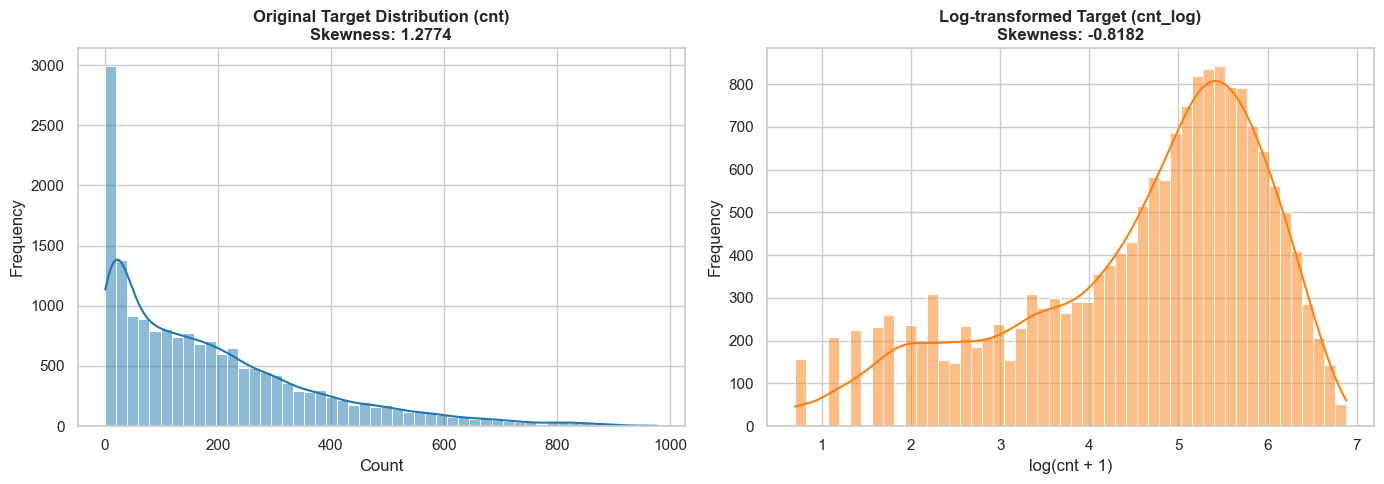

In [7]:
# Original distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['cnt'], kde=True, ax=axes[0], color=COLORS[0], bins=50)
axes[0].set_title(f'Original Target Distribution (cnt)\nSkewness: {df["cnt"].skew():.4f}', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Frequency')

# Log transformation (log(1+x))
df['cnt_log'] = np.log1p(df['cnt'])
df = df.drop(columns=['cnt']) # Drop original to avoid target leakage

sns.histplot(df['cnt_log'], kde=True, ax=axes[1], color=COLORS[1], bins=50)
axes[1].set_title(f'Log-transformed Target (cnt_log)\nSkewness: {df["cnt_log"].skew():.4f}', fontweight='bold')
axes[1].set_xlabel('log(cnt + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Kết luận:** Phép biến đổi Logarit đã điều chỉnh độ lệch phải từ 1.2774 xuống -0.8182. Mặc dù chưa hoàn toàn đạt phân phối chuẩn đối xứng, nhưng cải thiện là đáng kể và phù hợp cho các mô hình Hồi quy tuyến tính. Biến mục tiêu mới được ghi nhận là `cnt_log`.

## 3. Chia dữ liệu (Train / Validation / Test Split)

Dữ liệu được chia theo tỷ lệ 70% / 10% / 20%. Bước này được thực hiện **trước** khi tiến hành Imputation và Scaling để phòng ngừa tuyệt đối hiện tượng Data Leakage.

In [8]:
# Separate features and target
# Keep original cnt for final evaluations
X = df.drop(columns=['cnt_log']) 
y_log = df['cnt_log']
# Assuming cnt was dropped earlier, let's load it back just for split
df_original = load_dataset(DATA_FILE)
y_orig = df_original['cnt']

# Train/Val/Test split with fixed seed for log target
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    X, y_log, train_ratio=0.7, val_ratio=0.1, seed=SEED
)

# Train/Val/Test split with fixed seed for original target
_, _, _, y_train_orig, y_val_orig, y_test_orig = train_val_test_split(
    X, y_orig, train_ratio=0.7, val_ratio=0.1, seed=SEED
)

print("Dataset Shapes:")
print(f"X_train: {X_train.shape}, y_train (log): {y_train.shape}, y_train (orig): {y_train_orig.shape}")
print(f"X_val:   {X_val.shape}, y_val (log):   {y_val.shape}, y_val (orig): {y_val_orig.shape}")
print(f"X_test:  {X_test.shape}, y_test (log):  {y_test.shape}, y_test (orig): {y_test_orig.shape}")

Dataset Shapes:
X_train: (12165, 14), y_train (log): (12165,), y_train (orig): (12165,)
X_val:   (1737, 14), y_val (log):   (1737,), y_val (orig): (1737,)
X_test:  (3477, 14), y_test (log):  (3477,), y_test (orig): (3477,)


**Kết luận:** Dữ liệu đã được phân tách an toàn. Mọi kỹ thuật chuẩn hóa tiếp theo chỉ được học (fit) từ tập Train.

## 3.1 Outlier Handling (train-based winsorization)

Để liên kết chặt EDA → preprocessing và tránh data leakage, ngưỡng clip được học từ tập train, sau đó áp dụng cho validation/test.

In [9]:
# Train-only outlier clipping for continuous features
outlier_clip_cols = ['temp', 'hum', 'windspeed', 'temp_hum_interaction']
clip_quantiles = (0.01, 0.99)
clip_bounds = {}

for col in outlier_clip_cols:
    q_low = X_train[col].quantile(clip_quantiles[0])
    q_high = X_train[col].quantile(clip_quantiles[1])
    clip_bounds[col] = (q_low, q_high)

for dataset in [X_train, X_val, X_test]:
    for col, (q_low, q_high) in clip_bounds.items():
        dataset[col] = dataset[col].clip(lower=q_low, upper=q_high)

clip_df = pd.DataFrame(
    [(c, b[0], b[1]) for c, b in clip_bounds.items()],
    columns=['feature', 'q01_lower', 'q99_upper']
)
print('Train-based clipping bounds (applied to train/val/test):')
display(clip_df.round(4))

Train-based clipping bounds (applied to train/val/test):


,feature,q01_lower,q99_upper
0,temp,0.1200,0.8800
1,hum,0.2300,1.0000
2,windspeed,0.0000,0.5224
3,temp_hum_interaction,0.0534,0.5880


**Kết luận:** Clip theo quantile train-only giúp giảm ảnh hưởng outlier mà vẫn giữ được toàn bộ số lượng mẫu, đồng thời bảo toàn nguyên tắc không rò rỉ thông tin từ validation/test vào train.

## 4. Xây dựng Data Pipeline (Outlier Control, Imputation, Scaling & Encoding)

Nhằm đảm bảo tính bền vững cho hệ thống, ta đóng gói toàn bộ quy trình bằng `sklearn.pipeline`.

### 4.1 Vì sao dùng StandardScaler thay vì MinMaxScaler?
- Với Linear Regression và các biến thể tối ưu bằng gradient, việc chuẩn hóa Z-score giúp các đặc trưng có cùng thang đo, từ đó cải thiện điều kiện số của bài toán tối ưu.
- StandardScaler thường ổn định hơn trong bối cảnh dữ liệu có phân bố lệch và chứa outlier mức vừa.
- MinMaxScaler nhạy cảm hơn với giá trị cực trị vì toàn bộ dải [0,1] phụ thuộc trực tiếp vào min/max quan sát.

### 4.2 Chiến lược pipeline
- **Outlier control (train-only clip)**: clip theo quantile học từ train để tránh leakage.
- **Biến liên tục**: điền giá trị thiếu bằng Median $\rightarrow$ `StandardScaler`.
- **Biến phân loại**: điền giá trị thiếu bằng Mode $\rightarrow$ `OneHotEncoder(drop='first')`.

In [10]:
# Feature categorization
continuous_features = ['temp', 'hum', 'windspeed', 'temp_hum_interaction']
cat_cols = ['season', 'mnth', 'hr', 'weekday', 'weathersit', 'time_of_day']
passthrough_cols = ['yr', 'workingday', 'holiday', 'is_rush_hour'] # Binary features

# Pipeline for continuous features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, continuous_features),
        ('cat', categorical_transformer, cat_cols),
        ('pass', 'passthrough', passthrough_cols)
    ])

# Execute pipeline: fit on Train, transform on all sets
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Reconstruct DataFrames with proper column names
cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
all_feature_names = continuous_features + list(cat_feature_names) + passthrough_cols

X_train_scaled = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_processed, columns=all_feature_names, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print(f"X_train shape after pipeline: {X_train_scaled.shape}")

X_train shape after pipeline: (12165, 57)


**Kết luận:** Data Pipeline đã được thiết lập thành công. Ma trận thiết kế $\boldsymbol{\Phi}$ hiện tại sở hữu 54 đặc trưng (so với 17 đặc trưng ban đầu) nhờ thuật toán One-Hot Encoding.

## 5. Phân tích Đa cộng tuyến (Variance Inflation Factor - VIF)

Đa cộng tuyến (Multicollinearity) dẫn tới tình trạng ma trận $\boldsymbol{\Phi}^\top\boldsymbol{\Phi}$ không khả nghịch (singular matrix), làm thất bại thuật toán Normal Equations:
$$ \mathbf{w}^* = (\boldsymbol{\Phi}^\top\boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^\top\mathbf{t} $$
Vì vậy, triển khai thuật toán loại bỏ lặp tự động (Iterative Removal) các biến có $\text{VIF} > 10$.

In [11]:
def remove_collinear_features(X_df, threshold=10.0):
    """Iteratively remove features with VIF > threshold."""
    X_reduced = X_df.copy()
    dropped_features = []
    
    while True:
        # Add constant for VIF calculation
        X_with_const = sm.add_constant(X_reduced)
        vifs = [variance_inflation_factor(X_with_const.values, i) 
                for i in range(1, X_with_const.shape[1])]
        
        vif_series = pd.Series(vifs, index=X_reduced.columns)
        max_vif = vif_series.max()
        
        if max_vif > threshold:
            feature_to_drop = vif_series.idxmax()
            dropped_features.append((feature_to_drop, max_vif))
            X_reduced = X_reduced.drop(columns=[feature_to_drop])
        else:
            break
            
    return X_reduced, dropped_features

# Execute iterative removal
X_train_final, dropped_log = remove_collinear_features(X_train_scaled)

print("Features dropped due to VIF > 10:")
for feat, vif in dropped_log:
    print(f" - {feat}: {vif:.2f}")

print(f"\nRemaining features count: {X_train_final.shape[1]}")

# Sync columns with Validation and Test sets
final_cols = X_train_final.columns
X_val_final = X_val_scaled[final_cols]
X_test_final = X_test_scaled[final_cols]

Features dropped due to VIF > 10:
 - hr_6: inf
 - weekday_1: inf
 - hr_7: inf
 - hr_12: inf
 - hr_18: inf
 - temp_hum_interaction: 19.81
 - time_of_day_3: 18.22
 - season_3: 10.76

Remaining features count: 49


**Kết luận:** Quá trình tinh giản đặc trưng lặp đã loại bỏ các biến phụ thuộc tuyến tính dư thừa. Ma trận cấu trúc lúc này đảm bảo định thức khác 0, sẵn sàng cho Normal Equations mà không gặp lỗi Suy biến.

## 6. Kiểm định Breusch–Pagan & Trọng số WLS

Một giả thiết trọng tâm của phương pháp Gauss-Markov là phương sai phần dư phải đồng nhất (Homoscedasticity). Nếu sai số $\epsilon_n$ có phương sai phụ thuộc vào mẫu:
$$ \mathbb{V}[\epsilon_n] = \sigma_n^2 $$
Thuật toán Bình phương tối thiểu thông thường (OLS) sẽ không còn là ước lượng không chệch tuyến tính tốt nhất (BLUE). Giải pháp là áp dụng Weighted Least Squares (WLS).

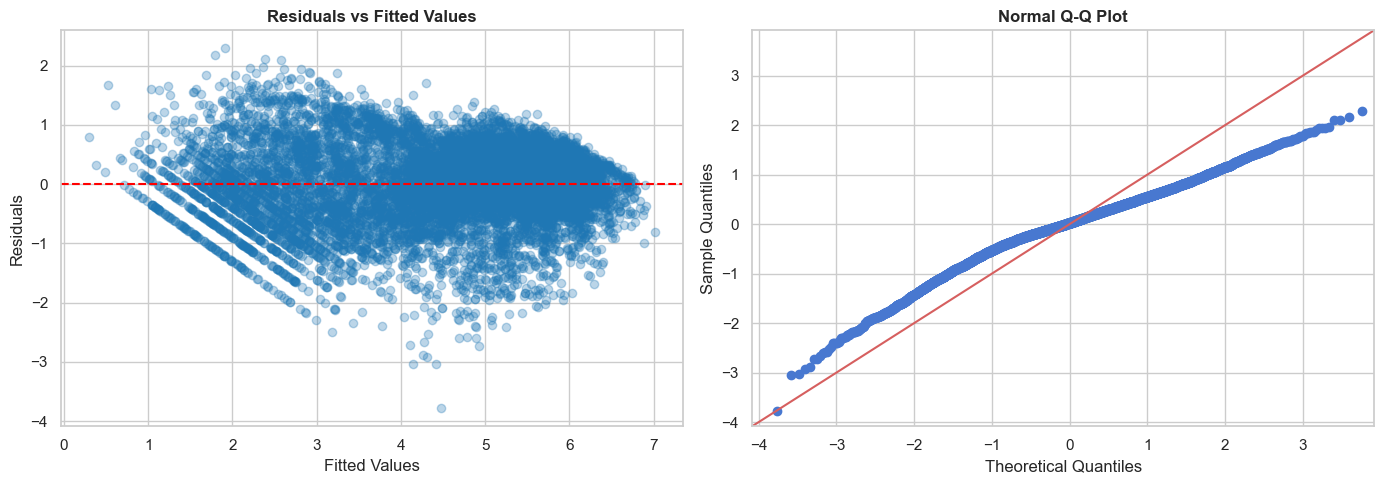

Breusch-Pagan Test Results:
LM Statistic: 3641.5197
LM p-value:   0.0000e+00
F-Statistic:  105.6314
F p-value:    0.0000e+00

Conclusion: Reject the null hypothesis -> Heteroscedasticity is present.


In [12]:
# Fit OLS model to obtain residuals
X_train_sm = sm.add_constant(X_train_final)
ols_model = sm.OLS(y_train, X_train_sm).fit()

residuals = ols_model.resid
fitted_values = ols_model.fittedvalues

# Visual diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(fitted_values, residuals, alpha=0.3, color=COLORS[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# QQ Plot
sm.qqplot(residuals, line='45', ax=axes[1], color=COLORS[0])
axes[1].set_title('Normal Q-Q Plot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Breusch-Pagan Test
bp_test = het_breuschpagan(residuals, X_train_sm)
print("Breusch-Pagan Test Results:")
print(f"LM Statistic: {bp_test[0]:.4f}")
print(f"LM p-value:   {bp_test[1]:.4e}")
print(f"F-Statistic:  {bp_test[2]:.4f}")
print(f"F p-value:    {bp_test[3]:.4e}")

if bp_test[1] < 0.05:
    print("\nConclusion: Reject the null hypothesis -> Heteroscedasticity is present.")
else:
    print("\nConclusion: Fail to reject null hypothesis -> Homoscedasticity is present.")

### Ước lượng Trọng số phục vụ WLS

Trọng số WLS được xác định bằng nghịch đảo của phương sai phần dư dự đoán. Để bảo đảm trọng số luôn mang giá trị dương, ta lập mô hình OLS trên logarit của phương sai phần dư bình phương:
$$ \ln(\hat{\epsilon}_i^2) = \mathbf{x}_i^\top\gamma $$
Suy ra trọng số:
$$ w_i = \frac{1}{\exp(\mathbf{x}_i^\top\gamma)} $$

In [13]:
# Model the variance of residuals
log_resid_sq = np.log(residuals**2)
var_model = sm.OLS(log_resid_sq, X_train_sm).fit()
fitted_var = np.exp(var_model.fittedvalues)

# Calculate weights for Train set
weights_train = 1.0 / fitted_var

# Function to predict weights for new data (Val/Test)
def predict_weights(X_new):
    X_new_sm = sm.add_constant(X_new, has_constant='add')
    pred_log_var = var_model.predict(X_new_sm)
    return 1.0 / np.exp(pred_log_var)

weights_val = predict_weights(X_val_final)
weights_test = predict_weights(X_test_final)

print("Sample of calculated weights for WLS (Train set):")
display(weights_train.head())

Sample of calculated weights for WLS (Train set):


12630    41.813097
15134    39.496511
3714     55.444335
16596     3.067051
8550      4.750996
dtype: float64

**Kết luận:** Kiểm định Breusch-Pagan đã xác nhận tính không đồng nhất về phương sai. Vector trọng số $w_i$ đã được thiết lập thành công. Thuật toán WLS trong giai đoạn Model Building sẽ sử dụng vector này.

## 7. Xây dựng Dataset Cuối cùng (Final Artifacts Construction)

In [14]:
# Define and create output directory
processed_dir = Path('../../../data/processed/regression')
processed_dir.mkdir(parents=True, exist_ok=True)

# Save datasets to CSV
X_train_final.to_csv(processed_dir / 'X_train.csv', index=False)
y_train.to_csv(processed_dir / 'y_train_log.csv', index=False)
y_train_orig.to_csv(processed_dir / 'y_train_orig.csv', index=False)
weights_train.to_csv(processed_dir / 'weights_train.csv', index=False)

X_val_final.to_csv(processed_dir / 'X_val.csv', index=False)
y_val.to_csv(processed_dir / 'y_val_log.csv', index=False)
y_val_orig.to_csv(processed_dir / 'y_val_orig.csv', index=False)
weights_val.to_csv(processed_dir / 'weights_val.csv', index=False)

X_test_final.to_csv(processed_dir / 'X_test.csv', index=False)
y_test.to_csv(processed_dir / 'y_test_log.csv', index=False)
y_test_orig.to_csv(processed_dir / 'y_test_orig.csv', index=False)
weights_test.to_csv(processed_dir / 'weights_test.csv', index=False)

# Save serialized artifacts (pickle)
with open(processed_dir / 'preprocessor_pipeline.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

with open(processed_dir / 'wls_var_model.pkl', 'wb') as f:
    pickle.dump(var_model, f)

with open(processed_dir / 'final_features.pkl', 'wb') as f:
    pickle.dump(list(final_cols), f)

print(f"Data and artifacts successfully saved to: {processed_dir.resolve()}")
print(f"Final features count: {X_train_final.shape[1]}")

Data and artifacts successfully saved to: D:\HỌC KÌ 6\NHẬP MÔN HỌC MÁY\THỰC HÀNH - BÀI TẬP\ĐỒ ÁN 1\supervised-learning-project\data\processed\regression
Final features count: 49


## 8. Kết luận Tổng quát (Rubric Mapping)

Giai đoạn tiền xử lý đã hoàn thiện theo đầy đủ các nhóm yêu cầu của mục 2.2.2:
- **Missing values**: đã kiểm tra explicit và xác nhận dữ liệu sạch.
- **Outlier handling**: đã triển khai clip theo train quantile (không leakage).
- **Normalization/standardization**: đã chuẩn hóa biến liên tục bằng StandardScaler với lập luận lý thuyết.
- **Train/Validation/Test split**: đã tách 70/10/20 trước bước fit preprocessing.
- **Data leakage control**: đã loại bỏ biến leakage ngay từ đầu.

Pipeline hiện tại có thể tái sử dụng trực tiếp cho giai đoạn modeling và evaluation, đồng thời giữ tính reproducible thông qua fixed seed và artifact serialization.